<a href="https://colab.research.google.com/github/AKutergin/dsp-seminars/blob/kutergin/seminars/2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое задание №2
## Амплитудная и фазовая модуляция: генерация, спектры, демодуляция и устойчивость к шумам

**Цель работы:**
- Научиться генерировать сигналы с амплитудной (АМ) и фазовой (ФМ) модуляцией.
- Исследовать спектральные характеристики модулированных сигналов.
- Изучить влияние индекса модуляции на спектр ФМ сигнала.
- Освоить демодуляцию АМ и ФМ с помощью преобразования Гильберта.
- Оценить устойчивость АМ и ФМ к амплитудному шуму на примере реального аудиосигнала.

**Необходимое ПО:** Python 3, библиотеки `numpy`, `matplotlib`, `scipy`, `ipywidgets`, `IPython.display`. Работа выполняется в Jupyter Notebook / Google Colab.

**Формат сдачи:** один Jupyter Notebook с кодом, графиками и текстовыми выводами. Имя файла: `2_Фамилия.ipynb`.

## Часть 1. Генерация и визуализация модулированных сигналов

### 1.1. Импорт библиотек и параметры

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
from scipy.signal import hilbert
import ipywidgets as widgets
from IPython.display import Audio, display

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

# Параметры дискретизации для демонстрации
fs = 10000                     # частота дискретизации (Гц)
T = 0.1                        # длительность сигнала (с)
t = np.linspace(0, T, int(fs*T), endpoint=False)

# Несущая
fc = 1000                      # частота несущей (Гц)
Ac = 1.0                       # амплитуда несущей

### 1.2. Модулирующий сигнал

В качестве модулирующего сигнала используйте сумму двух синусоид с частотами 100 Гц и 150 Гц, нормализованную к диапазону [-1, 1]. Постройте его график.

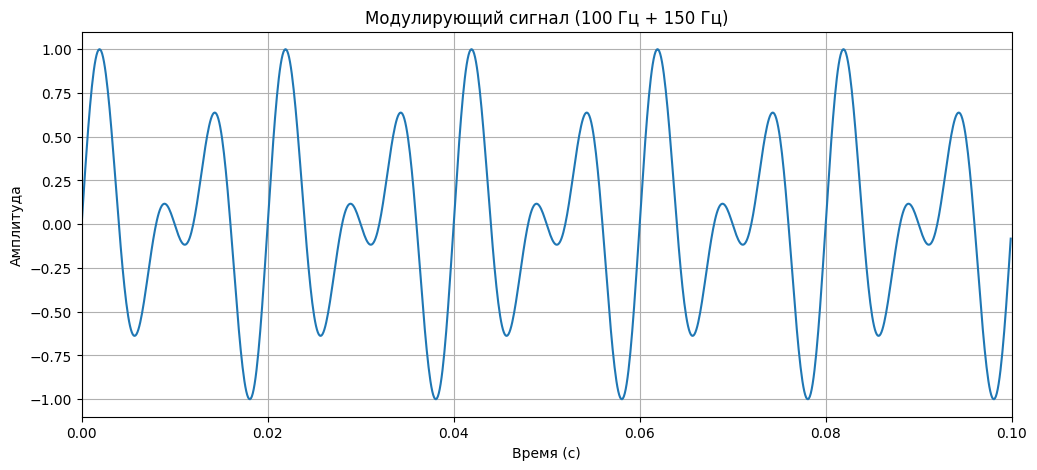

In [91]:
fm1 = 100
fm2 = 150
m_t_raw = np.sin(2 * np.pi * fm1 * t) + np.sin(2 * np.pi * fm2 * t)
m_t = m_t_raw / np.max(np.abs(m_t_raw))

plt.figure(figsize=(12, 5))
plt.plot(t, m_t)
plt.title(f'Модулирующий сигнал ({fm1} Гц + {fm2} Гц)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.xlim(0, 0.1)
plt.show()

### 1.3. Амплитудная модуляция (АМ)

Формула АМ:
$$s_{AM}(t) = A_c [1 + a_{AM}\cdot m(t)] \cos(2\pi f_c t)
$$
Параметр $a_{AM}$ регулирует _глубину модуляции_, он не может быть больше 1 (при $a_{AM}>1$ и исходном сигнале $m(t)$, нормализованном на единицу, амплитуда результирующего сигнала в некоторые промежутки времени становится отрицательной).

In [92]:
a_am = 0.2
s_am = Ac * (1 + a_am * m_t) * np.cos(2 * np.pi * fc * t)

### 1.4. Фазовая модуляция (ФМ)

Формула ФМ:
$$
s_{PM}(t) = A_c \cos(2\pi f_c t + \beta \cdot m(t)),
$$

где $\beta$ – индекс фазовой модуляции.

In [93]:
beta_pm = 5
s_pm = Ac * np.cos(2 * np.pi * fc * t + beta_pm * m_t)

Постройте на одном графике модулирующий сигнал и оба модулированных сигнала (АМ, ФМ). Оси и графики должны быть подписаны.

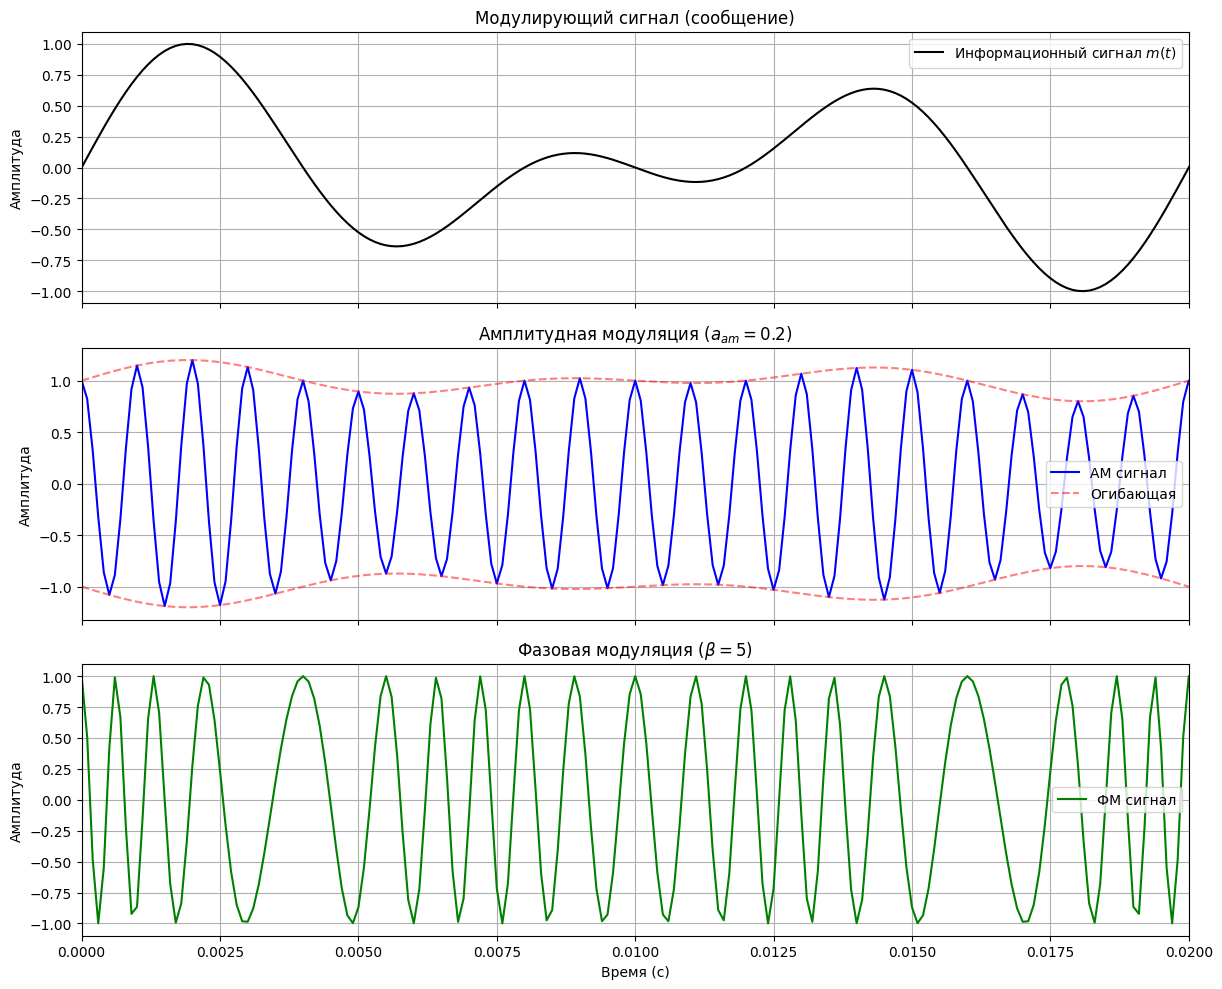

In [94]:
fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axs[0].plot(t, m_t, 'k', label='Информационный сигнал $m(t)$')
axs[0].set_title('Модулирующий сигнал (сообщение)')
axs[0].set_ylabel('Амплитуда')
axs[0].grid(True)
axs[0].legend()

axs[1].plot(t, s_am, 'b', label='АМ сигнал')
axs[1].plot(t, Ac*(1 + a_am * m_t), 'r--', alpha=0.5, label='Огибающая')
axs[1].plot(t, -Ac*(1 + a_am * m_t), 'r--', alpha=0.5)
axs[1].set_title(f'Амплитудная модуляция ($a_{{am}} = {a_am}$)')
axs[1].set_ylabel('Амплитуда')
axs[1].grid(True)
axs[1].legend()

axs[2].plot(t, s_pm, 'g', label='ФМ сигнал')
axs[2].set_title(f'Фазовая модуляция ($\\beta = {beta_pm}$)')
axs[2].set_xlabel('Время (с)')
axs[2].set_ylabel('Амплитуда')
axs[2].grid(True)
axs[2].legend()

plt.tight_layout()
plt.xlim(0, 0.02)
plt.show()

## Часть 2. Спектральный анализ модулированных сигналов

### 2.1. Функция построения амплитудного спектра
Реализуйте функцию построения амплитудного спектра ```plot_spectrum(s,fs,title)```
Значения аргументов:
* `s` - массив, содержащий значения сигнала
* `fs` - частота отсчётов сигнала
* `title` - заголовок графика, выводимый сверху

На графике по горизонтальной оси должна быть отложена частота в герцах, а по вертикальной - амплитуда гармоники. График должен строиться только для положительных значений частоты. Оси должны быть подписаны.

In [95]:
def plot_spectrum(s, fs, title):
    N = len(s)
    X = np.fft.fft(s)

    freqs = np.fft.fftfreq(N, 1/fs)

    half = N // 2
    freq_pos = freqs[:half]

    X_mag = (2.0 / N) * np.abs(X[:half])

    plt.figure(figsize=(12, 5))
    plt.plot(freq_pos, X_mag)
    plt.title(title)
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Амплитуда')
    plt.grid(True)

    plt.xlim(0, 2500)
    plt.show()


### 2.2. Спектр АМ

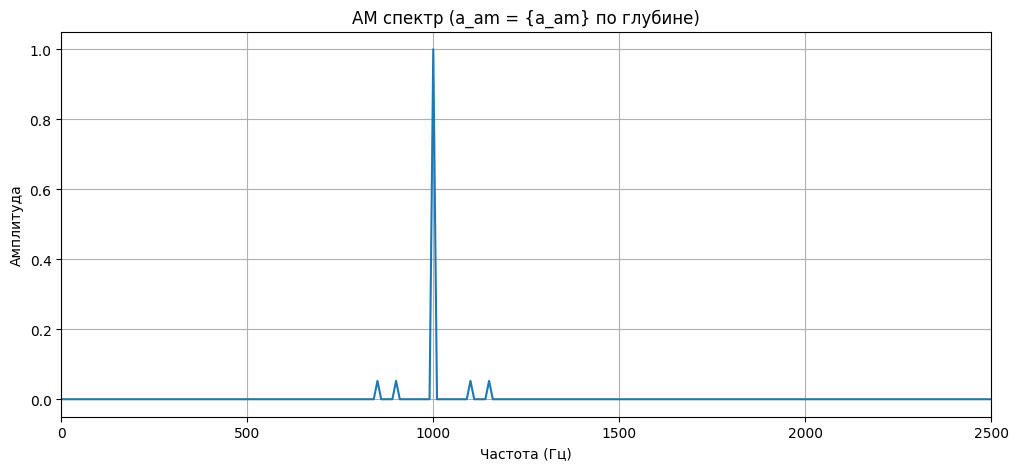

In [96]:
plot_spectrum(s_am, fs, 'АМ спектр (a_am = {a_am} по глубине)')

### 2.3. Спектр ФМ при разных индексах модуляции

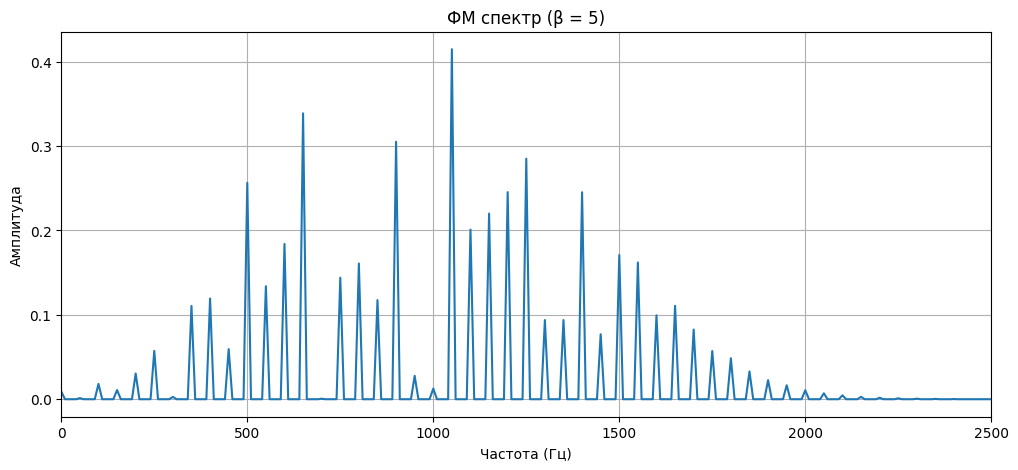

In [97]:
plot_spectrum(s_pm, fs, f'ФМ спектр (β = {beta_pm})')

Для ФМ постройте на одном графике спектры для разных индексов модуляции (например, β = 0.1, 0.3, 1, 2, 5, 10). Оси и графики должны быть подписаны.

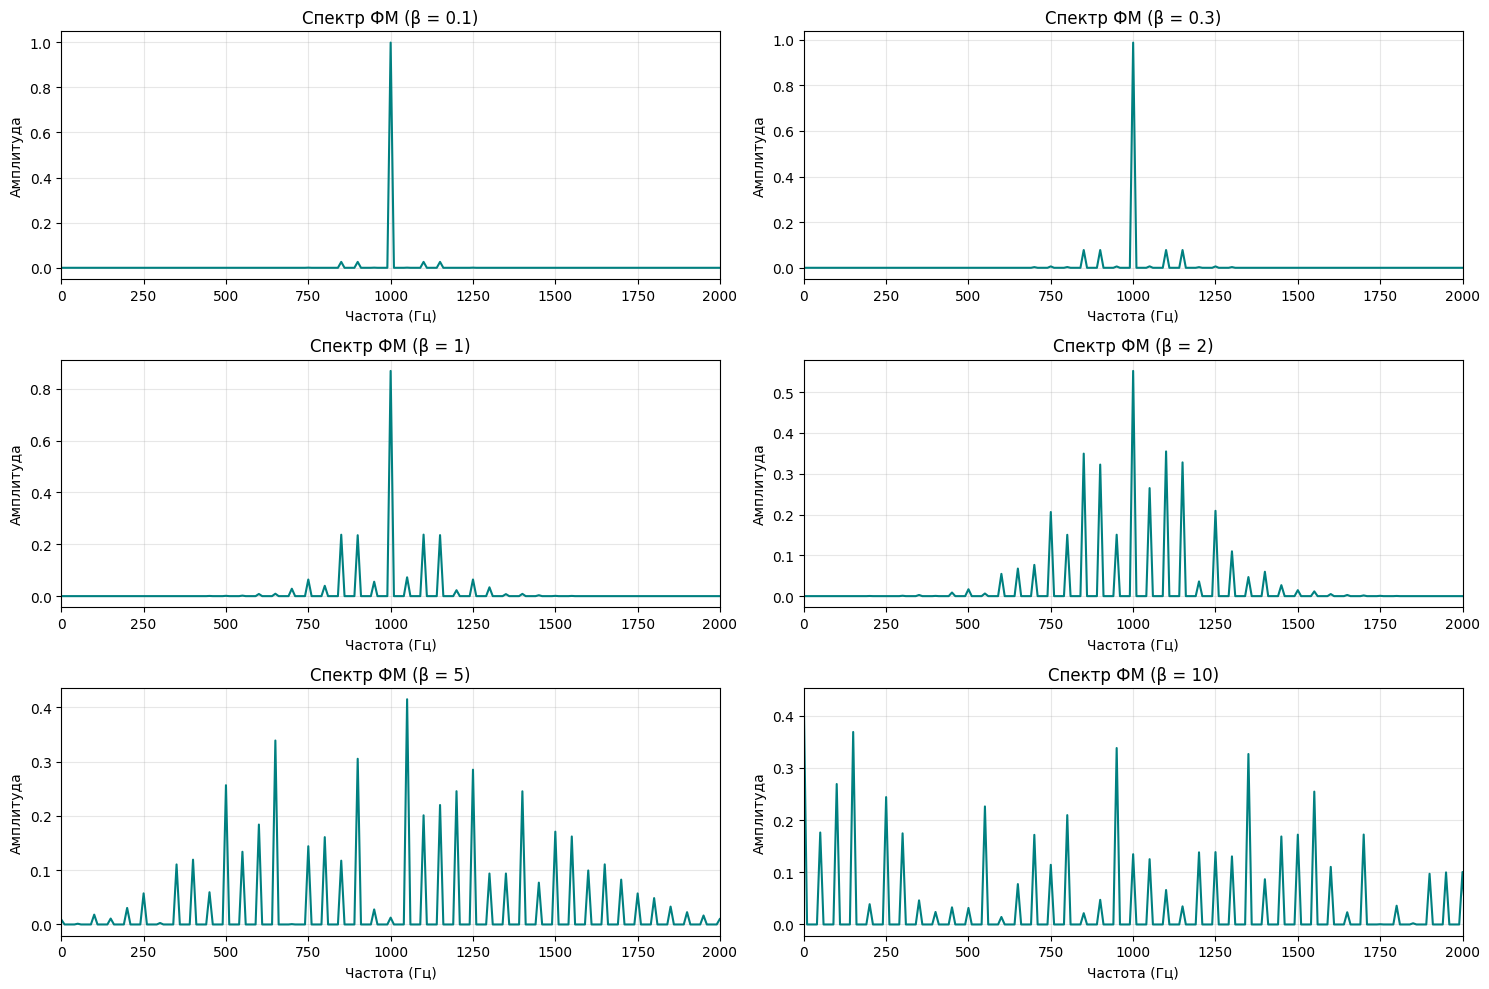

In [98]:
betas = [0.1, 0.3, 1, 2, 5, 10]
plt.figure(figsize=(15, 10))

for i, beta in enumerate(betas):
    s_pm_beta = Ac * np.cos(2 * np.pi * fc * t + beta * m_t)

    N = len(s_pm_beta)
    X = np.fft.fft(s_pm_beta)
    freqs = np.fft.fftfreq(N, 1/fs)[:N//2]
    X_mag = (2.0 / N) * np.abs(X[:N//2])

    plt.subplot(3, 2, i + 1)
    plt.plot(freqs, X_mag, color='teal')
    plt.title(f'Спектр ФМ (β = {beta})')
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Амплитуда')
    plt.xlim(fc - 1000, fc + 1000)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2.4. Интерактивное исследование спектра ФМ
Создайте интерактивный график для исследования зависимости спектра ФМ-сигнала от индекса модуляции.

In [99]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

def pm_spectrum(beta=5.0):
    s_pm_dynamic = Ac * np.cos(2 * np.pi * fc * t + beta * m_t)

    # Расчет БПФ
    N = len(s_pm_dynamic)
    X = np.fft.fft(s_pm_dynamic)
    freqs = np.fft.fftfreq(N, 1/fs)[:N//2]
    X_mag = (2.0 / N) * np.abs(X[:N//2])

    plt.figure(figsize=(12, 6))
    plt.plot(freqs, X_mag, color='darkcyan', linewidth=1.5)

    plt.title(f'Амплитудный спектр ФМ сигнала (Индекс модуляции $\\beta$ = {beta:.1f})')
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Амплитуда')

    plt.xlim(0, 3000)
    plt.ylim(0, 1.1)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)

    fm_max = 150
    bw_carson = 2 * (fm_max * (beta + 1))
    plt.annotate(f'Приблизительная ширина полосы (Карсон): ~{int(bw_carson)} Гц',
                 xy=(0.05, 0.9), xycoords='axes fraction', fontsize=12, color='red')

    plt.show()


widgets.interact(pm_spectrum,
                 beta=widgets.FloatSlider(min=0.1, max=20, step=0.1, value=5.0, description='Индекс $\\beta$:'));

interactive(children=(FloatSlider(value=5.0, description='Индекс $\\beta$:', max=20.0, min=0.1), Output()), _d…

**Вопросы:**
- Почему спектр АМ содержит только пять ярко выраженных компоненты (несущая и по две боковых с каждой стороны от неё)?
- Опишите, как выглядит спектр ФМ при малых β?
- Что происходит с амплитудой несущей и боковыми полосами ФМ при увеличении β?

1. Наш модулирующий сигнал $m(t)$ состоит из суммы двух синусоид (100 Гц и 150 Гц). При перемножении несущей $\cos(2\pi f_c t)$ и информационного сигнала в спектре происходит сдвиг частот:  $f_c$ ,  $f_c +- 100$,  $f_c +- 150$
2. Спектр ФМ визуально практически неотличим от спектра АМ
3. С ростом индекса модуляции ФМ-сигнал размножаются боковые полосы, общая ширина спектра начинает расти, колебание несущей.


## Часть 3. Демодуляция сигналов

### 3.1. Демодуляция АМ с помощью преобразования Гильберта

Преобразование Гильберта позволяет получить аналитический сигнал, огибающая которого содержит исходное сообщение.

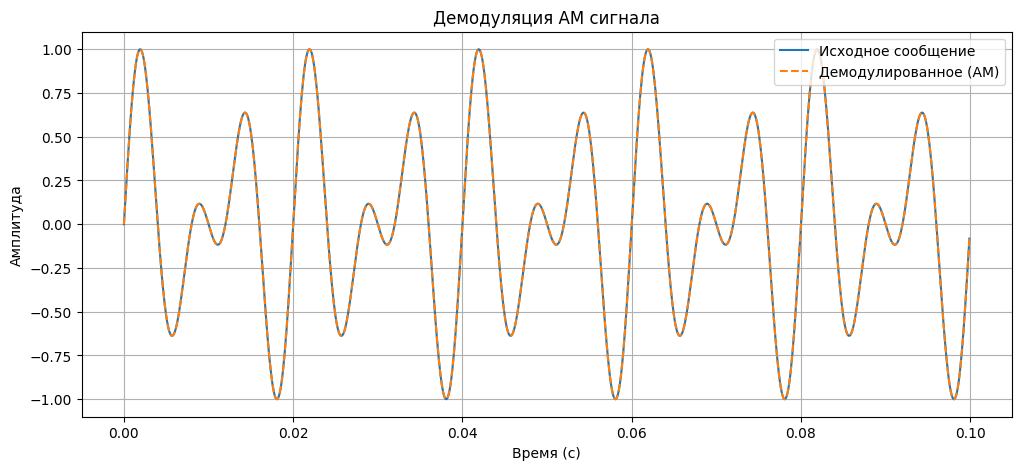

In [100]:
# Аналитический сигнал для АМ
analytic_am = hilbert(s_am)
envelope = np.abs(analytic_am) # огибающая = 1 + m(t)

# Убираем постоянную составляющую
demod_am = envelope - 1

# Нормализуем сигнал
demod_am = demod_am/a_am

# Сравнение с исходным
plt.figure()
plt.plot(t, m_t, label='Исходное сообщение')
plt.plot(t, demod_am, '--', label='Демодулированное (АМ)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Демодуляция АМ сигнала')
plt.legend()
plt.grid(True)
plt.show()

Вычислите среднеквадратичную ошибку между исходным и восстановленным сообщением с помощью функции `np.std`.

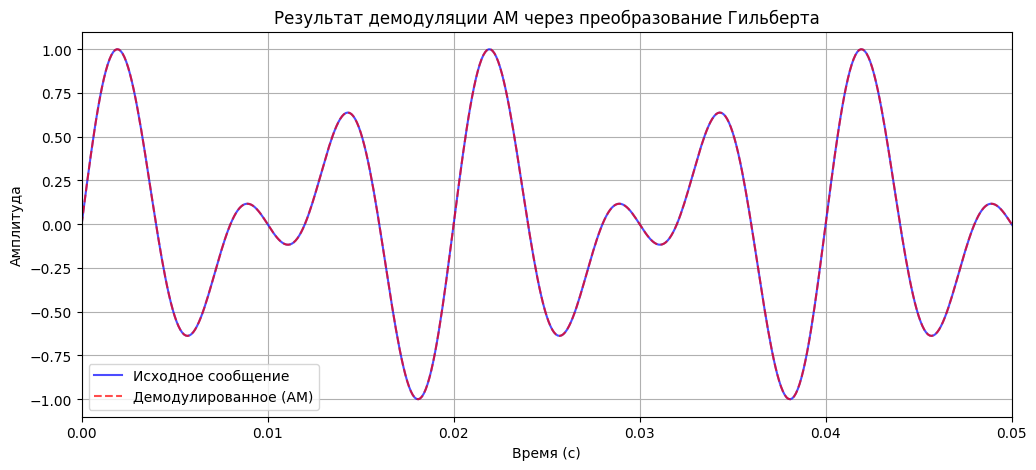

Среднеквадратичная ошибка (STD): 8.09e-14


In [101]:
error_std = np.std(m_t - demod_am)
plt.figure(figsize=(12, 5))
plt.plot(t, m_t, 'b', label='Исходное сообщение', alpha=0.7)
plt.plot(t, demod_am, 'r--', label='Демодулированное (АМ)', alpha=0.7)
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Результат демодуляции АМ через преобразование Гильберта')
plt.legend()
plt.grid(True)
plt.xlim(0, 0.05)
plt.show()

print(f"Среднеквадратичная ошибка (STD): {error_std:.2e}")

### 3.2. Демодуляция ФМ сигнала

Для ФМ информация заключена в отклонении фазы от линейного тренда. Используем аналитический сигнал и выделим мгновенную фазу.

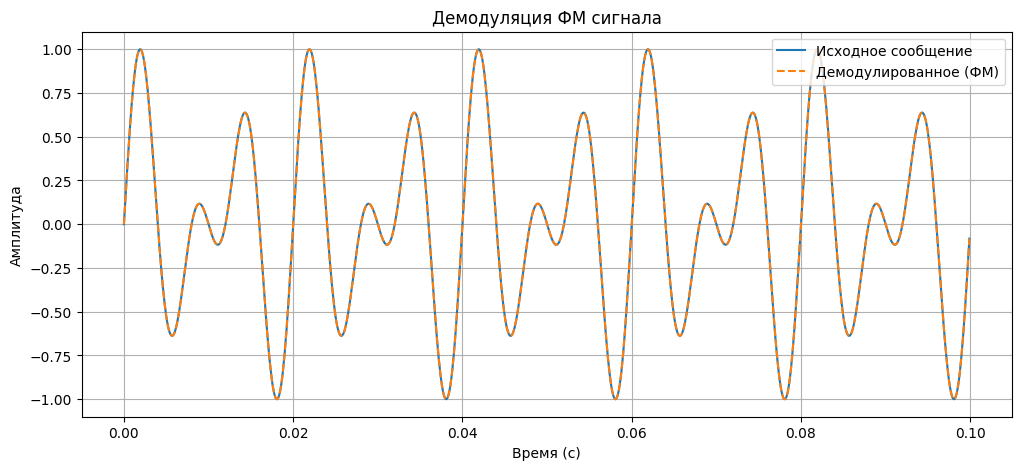

In [102]:
# Аналитический сигнал для ФМ
analytic_pm = hilbert(s_pm)
inst_phase = np.unwrap(np.angle(analytic_pm))   # развернутая фаза

phase_no_carrier = inst_phase - 2 * np.pi * fc * t

demod_pm = phase_no_carrier - np.mean(phase_no_carrier)

demod_pm = demod_pm / beta_pm

plt.figure()
plt.plot(t, m_t, label='Исходное сообщение')
plt.plot(t, demod_pm, '--', label='Демодулированное (ФМ)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Демодуляция ФМ сигнала')
plt.legend()
plt.grid(True)
plt.show()

**Вопрос:** Почему важно использовать `np.unwrap` для фазы?

np.unwrap анализирует разности между соседними элементами массива фазы, и если разность превышает порог $\pi$, функция добавляет или вычитает $2\pi$, «склеивая» график в непрерывную линию.

## Часть 4. Устойчивость к шумам

В этой части мы работаем с реальным аудиофайлом. Для примера WAV-файл расположен в том же репозитории, что и ноутбук по адресу `data/sample-3s.wav`, но его надо загрузить в Google Colab.

### 4.1. Загрузка аудио (или генерация тестового сигнала)

In [103]:
# Загружаем файл и сохраняем под именем audio.wav
!wget -O audio.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/sample-3s.wav"

--2026-03-29 16:35:44--  https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/sample-3s.wav
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/sample-3s.wav [following]
--2026-03-29 16:35:44--  https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/sample-3s.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 563756 (551K) [audio/wav]
Saving to: ‘audio.wav’

audio.wav           100%[===================>] 550.54K  --.-KB/s    in 0.04s   

2026-03-29 16:35:45 (12.2 MB/s) - ‘audio.wav’ saved [563756/563756]



In [104]:
fs_audio, melody_stereo = wavfile.read('audio.wav') # читаем wav-файл в массив numpy, в файл записан стереосигнал, поэтому melody_stereo будет содержать две дорожки (левую и правую)

melody = melody_stereo[:,0] # переходим к моносигналу, беря только одну из двух дорожек
melody = melody / np.max(np.abs(melody)) # нормализуем сигнал, чтобы корректно работала амплитудная модуляция

t_audio = np.linspace(0, melody.shape[0]/fs_audio, melody.shape[0], endpoint=False) # для визуализации создаём также массив временных отсчётов

print(f"Частота дискретизации: {fs_audio} Гц")
print(f"Длина временного ряда: {len(melody)}")
print(f"Тип данных: {melody.dtype}")

print("Исходное аудио:")
display(Audio(melody, rate=fs_audio))

Частота дискретизации: 44100 Гц
Длина временного ряда: 140928
Тип данных: float64
Исходное аудио:


Постройте графики самого сигнала и его спектра. Подпишите оси.

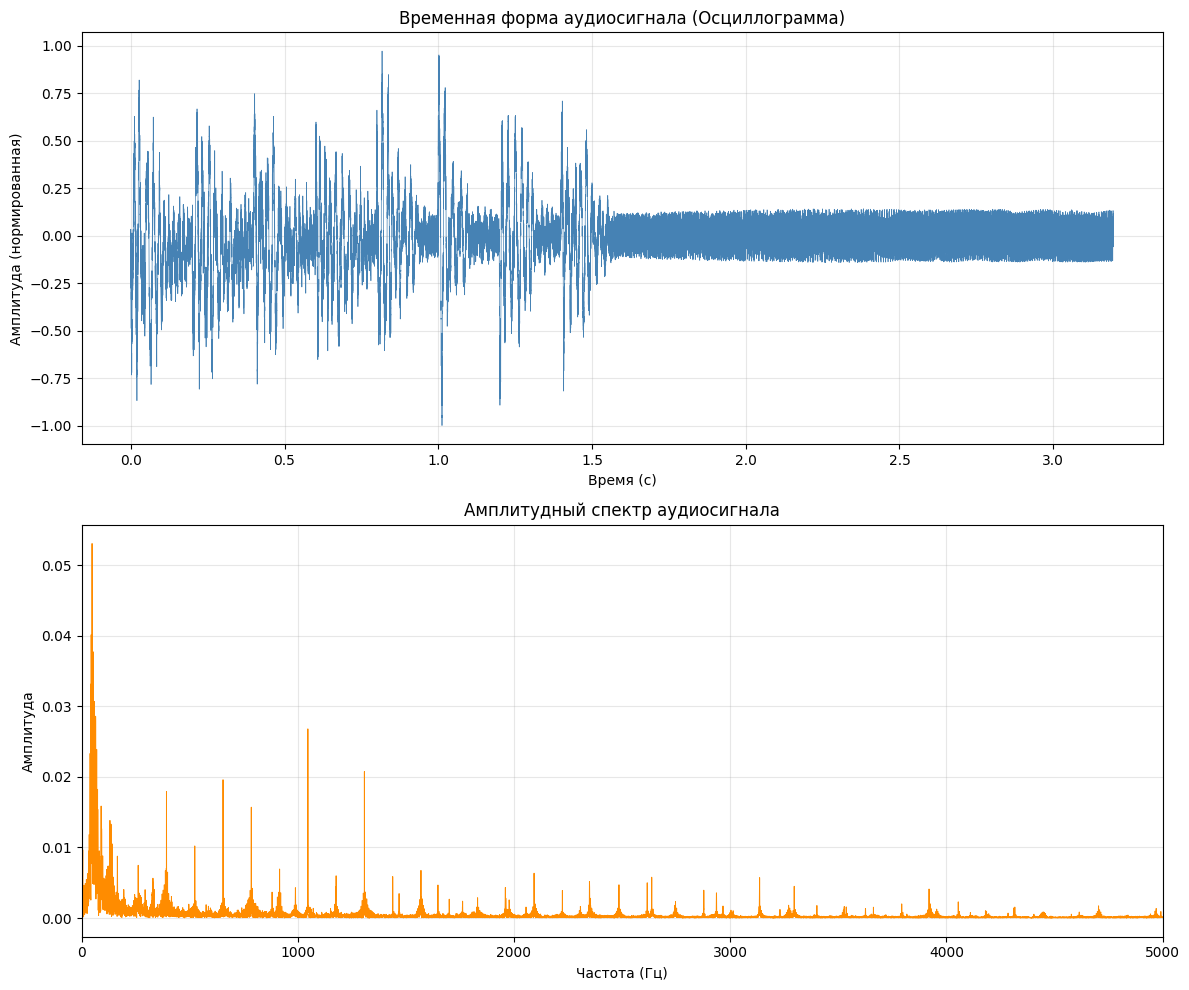

In [105]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 1, 1)
plt.plot(t_audio, melody, color='steelblue', linewidth=0.5)
plt.title('Временная форма аудиосигнала (Осциллограмма)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда (нормированная)')
plt.grid(True, alpha=0.3)

N_audio = len(melody)
X_audio = np.fft.fft(melody)
freqs_audio = np.fft.fftfreq(N_audio, 1/fs_audio)[:N_audio//2]
X_mag_audio = (2.0 / N_audio) * np.abs(X_audio[:N_audio//2])

plt.subplot(2, 1, 2)
plt.plot(freqs_audio, X_mag_audio, color='darkorange', linewidth=0.7)
plt.title('Амплитудный спектр аудиосигнала')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 5000)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Вопрос:** До каких частот наблюдаются заметные пики в сигнале? Подумайте, какую частоту несущей можно выбрать при частоте дискретизации 44,1 кГц, чтобы эти пики не потерять. Как на это влияет выбор индекса модуляции ФМ-сигнала?

Основная энергия аудиосигнала сосредоточена в низкочастотной области, однако заметные пики наблюдаются вплоть до 4000 Гц. При частоте дискретизации $f_s = 44.1$ кГц частота Найквиста составляет 22.05 кГц.

### 4.2. Подготовка к модуляции (интерполяция)

Выберите частоту несущей в соответствии с ответом на предыдущий вопрос (если восстановленный сигнал будет сильно зашумлён, попробуйте другие значения).

In [106]:
fc_high = 5000 # несущая 5 кГц
Ac = 1

### 4.3. Модуляция аудиосигнала
Сгенерируйте модулированные сигналы. Индекс модуляции для ФМ-сигнала выберите так, чтобы несильно портить модулируемый сигнал.

In [135]:
# АМ
a_am = 0.2
s_am_audio = Ac * (1 + a_am * melody) * np.cos(2 * np.pi * fc_high * t_audio)

# ФМ
beta_pm_audio = 2
s_pm_audio = Ac * np.cos(2 * np.pi * fc_high * t_audio + beta_pm_audio * melody)

### 4.4. Добавление шумов

**Амплитудный шум:** мультипликативный гауссов шум.

In [136]:
noise_amp = 0.1 * np.random.randn(len(t_audio))
s_am_noisy = s_am_audio * (1 + noise_amp)
s_pm_noisy = s_pm_audio * (1 + noise_amp)

### 4.5. Демодуляция сигналов

**Демодуляция АМ:**

Используйте преобразование Гильберта, чтобы демодулировать АМ-сигнал без шума, убедитесь, что качество звука изменилось незначительно.

In [109]:
analytic_audio_am = hilbert(s_am_audio)

envelope_audio = np.abs(analytic_audio_am)

demod_audio_am = (envelope_audio - Ac) / (Ac * a_am)

error_audio_am = np.std(melody - demod_audio_am)
print(f"Ошибка восстановления (STD) для чистого АМ: {error_audio_am:.2e}")

print("Восстановленное аудио (АМ без шума):")
display(Audio(demod_audio_am, rate=fs_audio))

Ошибка восстановления (STD) для чистого АМ: 1.11e-02
Восстановленное аудио (АМ без шума):


Демодулируйте зашумлёный АМ-сигнал.

In [110]:
analytic_noisy_am = hilbert(s_am_noisy)

envelope_noisy_am = np.abs(analytic_noisy_am)

demod_am_noisy = (envelope_noisy_am - Ac) / (Ac * a_am)

error_am_noisy = np.std(melody - demod_am_noisy)
print(f"STD ошибки зашумленного АМ: {error_am_noisy:.4f}")

print("Аудио после демодуляции зашумленного АМ:")
display(Audio(demod_am_noisy, rate=fs_audio))

STD ошибки зашумленного АМ: 0.0407
Аудио после демодуляции зашумленного АМ:


**Вопросы:**
* Изменилось ли качество звука?
* Зафиксируйте $a_{AM}=0{,}2$. Попробуйте поменять амплитуду шума. При каких значениях амплитуды вы слышите заметную разницу с оригиналом?
* Зафиксируйте амплитуду шума равную 0,01. Попробуйте поменять $a_{AM}$, при каких амплитудах модуляции начинаются заметные искажения? Сделайте вывод о соотношении $a_{AM}$ и допустимых уровнях шума.

1. Да, качество звука значительно ухудшилось.
2. При шуме 0.01 можно услышать заметную разницу с оригиналом
3. При $a_{AM}$ больше 1 начинаются заметные искажения
Качество восстановления АМ-сигнала определяется отношением сигнал/шум в огибающей.$$SNR_{envelope} \approx \frac{a_{AM}}{\sigma_{noise}}$$


**Демодуляция ФМ:**

Используйте метод аналитического сигнала для демодуляции ФМ-сигнала. Убедитесь, что качество звука изменилось незначительно.

In [137]:
analytic_audio_pm = hilbert(s_pm_audio)


inst_phase_audio = np.unwrap(np.angle(analytic_audio_pm))

phase_no_carrier_audio = inst_phase_audio - 2 * np.pi * fc_high * t_audio

demod_audio_pm = (phase_no_carrier_audio - np.mean(phase_no_carrier_audio)) / beta_pm_audio

error_audio_pm = np.std(melody - demod_audio_pm)
print(f"Ошибка восстановления (STD) для чистого ФМ: {error_audio_pm:.2e}")

print("Восстановленное аудио (ФМ без шума):")
display(Audio(demod_audio_pm, rate=fs_audio))

Ошибка восстановления (STD) для чистого ФМ: 9.13e-03
Восстановленное аудио (ФМ без шума):


Демодулируйте зашумлёный ФМ-сигнал.

In [138]:
analytic_noisy_pm = hilbert(s_pm_noisy)

inst_phase_noisy = np.unwrap(np.angle(analytic_noisy_pm))


phase_no_carrier_noisy = inst_phase_noisy - 2 * np.pi * fc_high * t_audio
demod_pm_noisy = phase_no_carrier_noisy - np.mean(phase_no_carrier_noisy)


demod_pm_noisy = demod_pm_noisy / beta_pm_audio

error_pm_noisy = np.std(melody - demod_pm_noisy)
print(f"STD ошибки зашумленного ФМ: {error_pm_noisy:.2e}")

print("Аудио после демодуляции зашумленного ФМ:")
display(Audio(demod_pm_noisy, rate=fs_audio))

STD ошибки зашумленного ФМ: 3.26e-02
Аудио после демодуляции зашумленного ФМ:


**Вопросы:**
* Изменилось ли качество звука?
* Зафиксируйте $\beta=2$. Попробуйте поменять амплитуду шума. При каких значениях амплитуды вы слышите заметную разницу с оригиналом?
* Зафиксируйте амплитуду шума равную 0,1. Попробуйте поменять $\beta$. Как субъективная величина искажений зависит от $\beta$?

1. Качество звука улучшилось
2. При шуме 0.1 слышна заметная разница
3. При малых $\beta$ звук становтися тихим, при очень больших $\beta$ появляется высокочастотные артефакты, из-за выхода из границы Найквиста


### 4.6. Сравнение спектров

Выберите значение амплитуды шума и величин $a_{AM}$ и $\beta$ так, чтобы искажения были заметны, но не велики. Постройте спектры исходного сигнала и сигналов, восстановлённых из зашумлённых АМ и ФМ-сигналов.

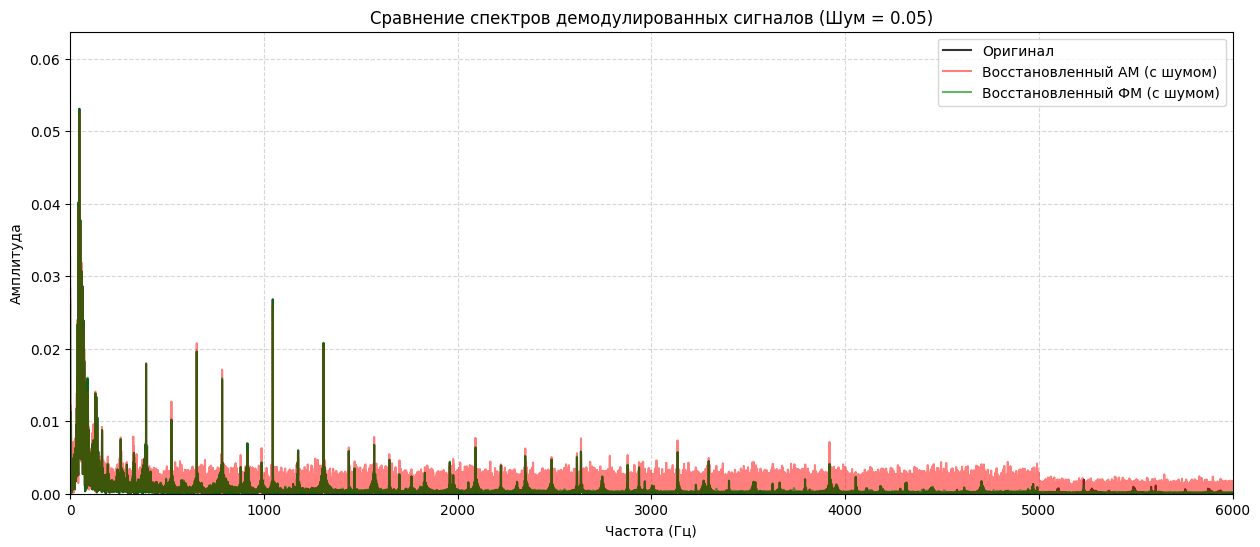

In [139]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

noise_level = 0.05
noise_amp = noise_level * np.random.randn(len(t_audio))

s_am_exp = Ac * (1 + 0.2 * melody) * np.cos(2 * np.pi * fc_high * t_audio) * (1 + noise_amp)
s_pm_exp = Ac * np.cos(2 * np.pi * fc_high * t_audio + 2 * melody) * (1 + noise_amp)


env_exp = np.abs(hilbert(s_am_exp))
demod_am_exp = (env_exp - Ac) / (Ac * 0.2)

phase_exp = np.unwrap(np.angle(hilbert(s_pm_exp)))
phase_no_carrier_exp = phase_exp - 2 * np.pi * fc_high * t_audio
demod_pm_exp = (phase_no_carrier_exp - np.mean(phase_no_carrier_exp)) / 2.0

def get_mag_spectrum(s, fs):
    N = len(s)
    X = np.fft.fft(s)
    freqs = np.fft.fftfreq(N, 1/fs)[:N//2]
    mag = (2.0 / N) * np.abs(X[:N//2])
    return freqs, mag

f_orig, m_orig = get_mag_spectrum(melody, fs_audio)
f_am, m_am = get_mag_spectrum(demod_am_exp, fs_audio)
f_pm, m_pm = get_mag_spectrum(demod_pm_exp, fs_audio)


plt.figure(figsize=(15, 6))

plt.plot(f_orig, m_orig, label='Оригинал', color='black', alpha=0.8, linewidth=1.5)
plt.plot(f_am, m_am, label='Восстановленный АМ (с шумом)', color='red', alpha=0.5)
plt.plot(f_pm, m_pm, label='Восстановленный ФМ (с шумом)', color='green', alpha=0.6)

plt.title(f'Сравнение спектров демодулированных сигналов (Шум = {noise_level})')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 6000)
plt.ylim(0, np.max(m_orig)*1.2)
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

**Вопрос:**
* Заметны ли визуально искажения спектров для случаев АМ и ФМ?

Для АМ: Искажения заметны очень сильно.
Для ФМ: Искажения визуально практически незаметны.

Постройте спектры АМ и ФМ сигналов. Зафиксируйте $\beta=2$, подберите $a_{AM}$ так, чтобы амплитуды гармоник в обоих случаях были сравнимы по величине.

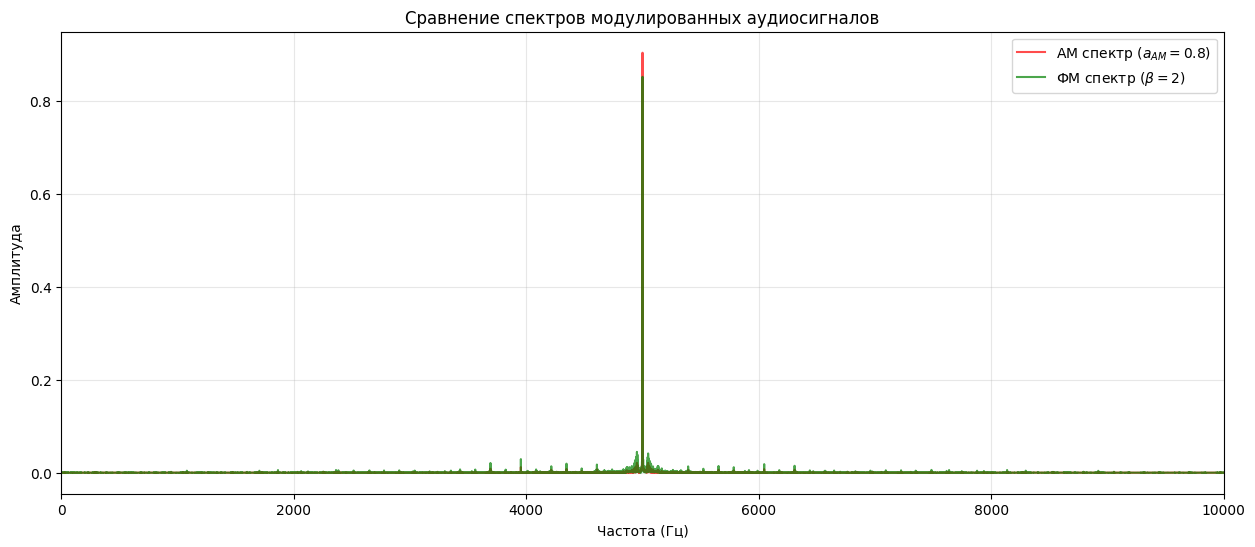

In [140]:

beta_comp = 2
a_am_comp = 0.8

s_am_comp = Ac * (1 + a_am_comp * melody) * np.cos(2 * np.pi * fc_high * t_audio)
s_pm_comp = Ac * np.cos(2 * np.pi * fc_high * t_audio + beta_comp * melody)


N = len(melody)
freqs = np.fft.fftfreq(N, 1/fs_audio)[:N//2]
spec_am = (2.0/N) * np.abs(np.fft.fft(s_am_comp)[:N//2])
spec_pm = (2.0/N) * np.abs(np.fft.fft(s_pm_comp)[:N//2])

plt.figure(figsize=(15, 6))
plt.plot(freqs, spec_am, label=f'АМ спектр ($a_{{AM}}={a_am_comp}$)', color='red', alpha=0.7)
plt.plot(freqs, spec_pm, label=f'ФМ спектр ($\\beta={beta_comp}$)', color='green', alpha=0.7)

plt.title('Сравнение спектров модулированных аудиосигналов')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(fc_high - 5000, fc_high + 5000)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Вопрос:**
* При какой амплитуде шума в этом случае вы слышите заметные искажения АМ сигнала? А ФМ сигнала? Сделайте вывод.

Для АМ-сигнала: Заметные искажения начинают проявляться уже при амплитуде шума в районе 0.01
Для ФМ-сигнала: Заметные искажения начинают проявляться значительно позже — при амплитуде шума выше 0.1
На основе проведенного сравнения спектров и прослушивания можно сделать следующие выводы:
1. ФМ на порядок устойчивее к амплитудным помехам, чем АМ.
2. Платой за чистоту звука в ФМ является ширина полосы.
